In [1]:
# Cell 1 — All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("All libraries loaded ✓")

All libraries loaded ✓


In [2]:
# Cell 2 — Load dataset
# Replace 'phishing_email.csv' with your actual filename if different
df = pd.read_csv('phishing_email.csv')

# Always look at the first 5 rows to understand what you have
print("Shape:", df.shape)          # (rows, columns)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (82486, 2)

Column names: ['text_combined', 'label']

First 5 rows:


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [3]:
# Cell 3 — Explore the data
# Check how many phishing vs safe emails exist
print("Label counts:")
print(df['label'].value_counts())   # adjust 'label' to your actual column name

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Label counts:
label
1    42891
0    39595
Name: count, dtype: int64

Missing values:
text_combined    0
label            0
dtype: int64

Data types:
text_combined    object
label             int64
dtype: object


In [6]:
print(df.columns.tolist())
print(df.head(2))

['text_combined', 'label']
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...      0
1  nom actual vols 24 th forwarded sabrae zajac h...      0


In [7]:
# Cell 4 — Clean the data

df = df.dropna(subset=['text_combined', 'label'])

df = df.rename(columns={'text_combined': 'email_text', 'label': 'is_phishing'})

df['is_phishing'] = df['is_phishing'].astype(int)

df = df.reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print(df['is_phishing'].value_counts())

Cleaned dataset shape: (82486, 2)
is_phishing
1    42891
0    39595
Name: count, dtype: int64


In [8]:
# Cell 5 — Create extra numeric features from email text

import re

def count_urls(text):
    """Count how many URLs (http/https links) are in the email."""
    return len(re.findall(r'https?://', str(text)))

def count_keywords(text):
    """Count phishing red-flag words in the email."""
    keywords = [
        'click here', 'verify', 'account', 'password', 'urgent',
        'winner', 'bank', 'login', 'confirm', 'suspended',
        'limited time', 'act now', 'free', 'prize', 'security alert'
    ]
    text_lower = str(text).lower()
    return sum(1 for kw in keywords if kw in text_lower)

# Apply both functions to create new columns
df['url_count'] = df['email_text'].apply(count_urls)
df['keyword_count'] = df['email_text'].apply(count_keywords)

print("New features added. Sample:")
print(df[['email_text', 'url_count', 'keyword_count', 'is_phishing']].head(3))

New features added. Sample:
                                          email_text  url_count  \
0  hpl nom may 25 2001 see attached file hplno 52...          0   
1  nom actual vols 24 th forwarded sabrae zajac h...          0   
2  enron actuals march 30 april 1 201 estimated a...          0   

   keyword_count  is_phishing  
0              0            0  
1              0            0  
2              0            0  


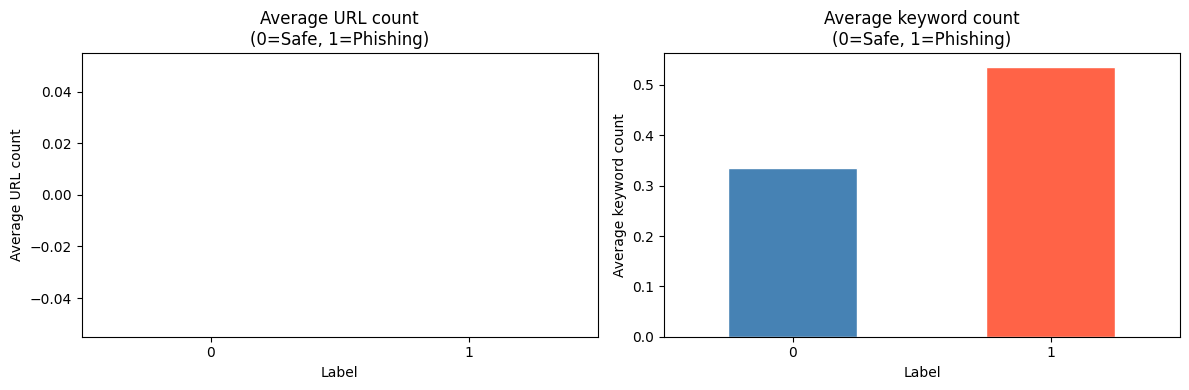

Chart saved as feature_comparison.png


In [9]:
# Cell 6 — Visualize feature differences between phishing vs safe

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# URL count by label
df.groupby('is_phishing')['url_count'].mean().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_title('Average URL count\n(0=Safe, 1=Phishing)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Average URL count')
axes[0].tick_params(axis='x', rotation=0)

# Keyword count by label
df.groupby('is_phishing')['keyword_count'].mean().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[1].set_title('Average keyword count\n(0=Safe, 1=Phishing)')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Average keyword count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150)
plt.show()
print("Chart saved as feature_comparison.png")

In [10]:
# Cell 7 — Split into training set and test set

X = df['email_text']          # raw email text (the model input)
y = df['is_phishing']         # labels: 0=safe, 1=phishing

# 80% for training, 20% for testing
# stratify=y ensures both sets have the same ratio of phishing to safe emails
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples:  {len(X_train)}")
print(f"Testing samples:   {len(X_test)}")
print(f"\nPhishing ratio in train: {y_train.mean():.2%}")
print(f"Phishing ratio in test:  {y_test.mean():.2%}")

Training samples:  65988
Testing samples:   16498

Phishing ratio in train: 52.00%
Phishing ratio in test:  52.00%


In [12]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words='english'
    )),
    ('classifier', MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)
print("Naive Bayes model trained ✓")

train_acc = nb_pipeline.score(X_train, y_train)
print(f"Training accuracy: {train_acc:.2%}")

Naive Bayes model trained ✓
Training accuracy: 96.39%


In [13]:
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words='english'
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest model trained ✓")

train_acc = rf_pipeline.score(X_train, y_train)
print(f"Training accuracy: {train_acc:.2%}")

Random Forest model trained ✓
Training accuracy: 100.00%


In [14]:
nb_pred = nb_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("=" * 40)
print(f"Naive Bayes accuracy:    {nb_acc:.2%}")
print(f"Random Forest accuracy:  {rf_acc:.2%}")
print("=" * 40)

best_model = rf_pipeline if rf_acc >= nb_acc else nb_pipeline
best_name  = "Random Forest" if rf_acc >= nb_acc else "Naive Bayes"
best_pred  = rf_pred if rf_acc >= nb_acc else nb_pred
print(f"\nBest model: {best_name}")

Naive Bayes accuracy:    95.99%
Random Forest accuracy:  98.65%

Best model: Random Forest


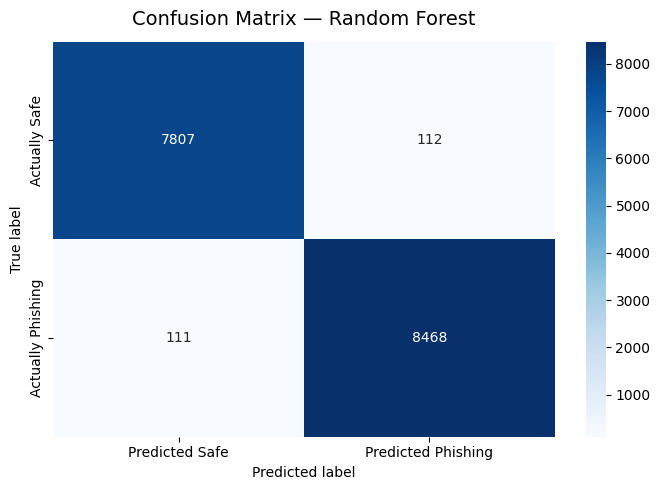


True Negatives  (safe correctly identified):    7807
False Positives (safe wrongly flagged as phish): 112
False Negatives (phish missed by model):         111
True Positives  (phishing correctly caught):     8468


In [15]:
# Cell 11 — Confusion matrix (shows where the model gets confused)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,          # show numbers inside each cell
    fmt='d',             # format as integers
    cmap='Blues',
    xticklabels=['Predicted Safe', 'Predicted Phishing'],
    yticklabels=['Actually Safe', 'Actually Phishing']
)
plt.title(f'Confusion Matrix — {best_name}', fontsize=14, pad=12)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Explain what each cell means
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (safe correctly identified):    {tn}")
print(f"False Positives (safe wrongly flagged as phish): {fp}")
print(f"False Negatives (phish missed by model):         {fn}")
print(f"True Positives  (phishing correctly caught):     {tp}")

In [16]:
# Cell 12 — Detailed precision, recall, F1 report

print(f"Classification Report — {best_name}")
print("=" * 55)
print(classification_report(
    y_test, best_pred,
    target_names=['Safe (0)', 'Phishing (1)']
))

Classification Report — Random Forest
              precision    recall  f1-score   support

    Safe (0)       0.99      0.99      0.99      7919
Phishing (1)       0.99      0.99      0.99      8579

    accuracy                           0.99     16498
   macro avg       0.99      0.99      0.99     16498
weighted avg       0.99      0.99      0.99     16498



In [17]:
# Cell 13 — Try the model on a brand new email you write yourself

sample_emails = [
    # Phishing-style email
    "URGENT: Your bank account has been suspended. Click here immediately to verify your password and avoid losing access: http://secure-bank-login.fake.com",
    
    # Safe email
    "Hi team, please find attached the notes from yesterday's product meeting. Let me know if you have questions.",
    
    # Write your own!
    "Congratulations! You have won a $1000 gift card. Act now and claim your free prize by clicking the link below."
]

predictions = best_model.predict(sample_emails)
labels = {0: "✅ SAFE", 1: "🚨 PHISHING"}

print(f"Model: {best_name}\n")
for email, pred in zip(sample_emails, predictions):
    print(f"Email:  {email[:80]}...")
    print(f"Result: {labels[pred]}\n")

Model: Random Forest

Email:  URGENT: Your bank account has been suspended. Click here immediately to verify y...
Result: 🚨 PHISHING

Email:  Hi team, please find attached the notes from yesterday's product meeting. Let me...
Result: ✅ SAFE

Email:  Congratulations! You have won a $1000 gift card. Act now and claim your free pri...
Result: 🚨 PHISHING

